# Assignment 1: Transformers & Generative Pretrained Transformer (GPT)

The goal of this assignment is to master the **Transformer architecture**, which is the engine behind modern Large Language Models (LLMs) such as ChatGPT, Gemini, and DeepSeek. We will implement a compact, decoder-only transformer from scratch, closely following the [NanoGPT](https://github.com/karpathy/nanoGPT) project by Andrej Karpathy.

We will train this model on textual figure captions from the [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K), which contains descriptions of histopathology images (specifically melanocytic lesions). After training, your model will be able to generate **synthetic captions** when prompted with a short starting sequence. Note that at this point we do not associate these captions with image data. We will go into vision-language models that can jointly model both image and text data in the next assignment. For now, we focus on text, but, as you will see in Assignment 2, extending the Transformer architecture to model image data is a straightforward extension. 

This dataset was specifically prepared for this course (work done by Martina Hanusova). While this dataset is certainly not as large as the massive corpora used to train ChatGPT and consists of open-access figures and captions rather than medical images and clinical reports, it offers two  advantages. First, the content is highly dense with relevant medical terminology, which makes the training process efficient. Second, because we are using public data from medical publications, we avoid the complex legal and ethical hurdles associated with handling private patient data.

## Preparation

We start with the assumption that you have a solid understanding of fundamental machine learning and neural network concepts, such as linear regression, gradient descent, backpropagation, and loss functions; if you need a refresher, please review materials from the previous courses (e.g. 8BB020 Introduction to Machine Learning). You must prepare for this assignment by mastering the Transformer architecture, specifically understanding self-attention mechanisms in neural networks and the distinction between encoder models and the decoder-only architectures (like GPT) used for generative tasks.

Beyond the architecture, you must also familiarize yourself with the basics of Computational Pathology to understand the medical context of our dataset (we will be generating captions for H&E stained histopathology images).

This is a list of materials that you can use to learn the topic of Transformers and prepare for the flipped classrooms:

| Type | Length | Link | Why is it relevant? |
| :--- | :--- | :--- | :--- |
| Video | 8 min. | [Large Language Models explained briefly (3Blue1Brown)](https://www.youtube.com/watch?v=LPZh9BOjkQs&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=5) | This video from the [3Blue1Brown](https://www.3blue1brown.com/) YouTube channel was originally made as an exhibit for Computer History Museum. It gives a very "gentle" and high-level introduction of the mechanics of how (large) language models work and are trained. This includes the concept of autoregressive modelling (predicting the next word in a sequence), (pre)-training of large language models from text datasets (the "P" in GPT stands for "pretrained") as well as reinforcement learning with human feedback. While in this course we will keep to training of (relatively small) language models, it is good to have the complete picture.  The entire 3Blue1Brown channel is a very high-quality source of educational content on a wide range of topics. In fact, the entire [Neural networks]() playlist is highly recommended, also as a refresher to more fundamental concepts such as backpropagation. | 
| Paper | 10 pg. | [Attention Is All You Need (Vaswani et al.)](https://arxiv.org/abs/1706.03762) | This is the paper that introduced the Transformer architecture to the world. It is a must-read for anyone interested in the subject. The paper is relatively short (10 pages without references), however it can be a bit "dense" for beginners. That is ok, as the most important thing to understand is the tokenization of text and the self-attention mechanism. Both of these concepts are also covered in the next two recommended videos so it is best that you iterate between watching the videos and reading the paper. Note that one thing that might be particularly confusing is that the neural network architecture in this paper has both an encoder and decoder part. This is because the application that is addressed here is natural language translation (machine translation). In this setup, the encoder part is used to encode the text in the original language and the decoder is used to translate this encoded text into the target language. In this course we will focus on decoder-only architectures, which are used for generative tasks such as text generation. | 
| Video | 27 min. | [Transformers, the tech behind LLMs (3Blue1Brown)](https://www.youtube.com/watch?v=wjZofJX0v4M&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) | This video provides a visual overview of the data flow within a Transformer, specifically focusing on GPT-style (decoder-only) models. It explains tokenization, embeddings (how vectors encode semantic meaning), and the final softmax layer used to predict the next token. It serves as a high-level roadmap of the architecture before diving into specific components in the next video. |
| Video | 26 min. | [Attention in transformers (3Blue1Brown)](https://www.youtube.com/watch?v=eMlx5fFNoYc&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) |This chapter breaks down the Attention mechanism (Self-Attention), which is the core innovation of the Transformer. It details the Query, Key, and Value (Q, K, V) matrices and visualizes how the attention pattern is calculated via dot products. It explains how the model uses these to "attend" to relevant context (updating word meanings based on surrounding words) and introduces concepts like multi-head attention and masking. |
| Interactive tool | ~25 min. | [Transformer explainer (poloclub)](https://poloclub.github.io/transformer-explainer/)| This is a great interactive tool that explains in steps how transformer models for language work and make predictions. It should take around 25 minutes to go over all the steps in the tool for one example, but it might be useful to spend some more time and look at different examples. | 
| Video | 120 min. | [Let's build GPT: from scratch, in code, spelled out (Andrej Karpathy)](https://www.youtube.com/watch?v=kCc8FmEb1nY) | This video series provides a step-by-step guide to building a GPT-style transformer from scratch. It covers the entire process, from data preparation to model training and evaluation. It is a great resource for understanding the mechanics of how GPT-style models work and how to implement them in code. It is **optional** in a sense that it is not required for the exercises, but might be very useful for understanding the dataset and **formulating an research question for the open assignment.** |
| Paper | 11 pg. | [From melanocytes to melanomas (Shain et al.)](https://www.nature.com/articles/nrc.2016.37) | This review paper provides a good overview of the biology of melanocytic lesions and the histopathology of melanocytic lesions. It is a good resource to understand the medical context of our dataset.|
| Paper | 35 pg. | [Large Language Models: A Survey (Minaee et al.)](https://arxiv.org/abs/2402.06196) | This survey paper is a good resource to get the "big picture" of various large language models and how they differ in their methodology and implementation. Treat this resource as **optional**. It is not required to complete the exercises in this assignments, but it is very useful to get a broader understanding of the state-of-the-art, which you might find useful for **generating ideas for the open assignment** or future projects (e.g. for your BEP or MSc projects). |

## Exercises: Theory

⚠️ *The answers to the theory exercises are NOT to be submitted as part of the assignment deliverables. They can, however, be used to check your understanding of the materials and to prepare for the flipped classroom. You CAN include your discussion about the exercises in the flipped classroom log.*

#### Exercise T.1 

A GPT model is autoregressive, meaning it generates text strictly one token at a time. It predicts the first next token, appends it to the sequence, and uses that updated sequence to predict the second token. This is a serial process.

In contrast, many other neural networks process their entire input in parallel (all at once) to maximize speed.

If we modified the architecture to predict every token in a paragraph simultaneously (in parallel) rather than one by one, is the resulting text likely to be grammatically coherent? Explain your reasoning.

#### Exercise T.2

In this assignment (as you will see later), we define tokens to be individual characters (e.g., 'a', 'b', 'c'). This keeps our vocabulary small and the implementation simple. In contrast, the standard practice for modern Large Language Models is to use sub-word tokenization, which groups frequent character patterns into single tokens to process text more efficiently. 

Assume that we take this concept one step further and define tokens to be entire sentences. What would be the consequence of this when generating text?

#### Exercise T.3

The core concept of a Transformer is self-attention, which allows a token to look at other tokens to gather context. In a Decoder-only model (like GPT), we apply a specific constraint called Causal Self-Attention (or "Masked" Self-Attention) during training. This forces every token to look only at itself and the tokens that came before it.

This is different from Encoder models, which use Bidirectional Attention, allowing tokens to see the entire sentence (past and future) at once.

Assume that during training, we feed the entire completed sentence into the model at once. Will this model still be useful for generating text? Explain your reasoning. 

#### Exercise T.4 

Decoder-only models (like GPT) are mathematically optimized to maximize the probability of the text sequence. This means that if they were trained with medical report data, they strive to generate text that "looks" and "sounds" like a real medical report. They are not optimized to check for factual truth.

Assume that your trained model generates a synthetic pathology caption that includes specific quantitative details: "The sample shows a high mitotic rate of 8 figures per 10 HPF."

Why is this specific type of error (a plausible-sounding number) significantly more dangerous to a clinician than if the model had just generated obvious gibberish (e.g., "rate figures high 8 10" )?

#### Exercise T.5 

If we want to train a model that generates a pathology report based on medical imaging data, we would need a joint vision-language model. We will touch on this in the next assignment. For now, assume that we want to generate a report based on some medical test or observations that we can represent as text data and make them part of the starting sequence that we use to prompt further generation.

Consider the following example of how such a model would operate:

Input Sequence (Provided by User): "Clinical Indication: Patient has a rapidly growing, asymmetrical black lesion on the left shoulder. Rule out Melanoma. Gross Description: ..."

Generated Continuation (Predicted by Model): "...Specimen consists of a skin ellipse measuring 2.0 x 1.5 cm. Microscopic examination reveals a proliferation of atypical melanocytes arranged in nests at the dermo-epidermal junction. There is upward migration of cells (pagetoid spread). DIAGNOSIS: MALIGNANT MELANOMA."

Would such a model be useful in clinical practice? Motivate your answer.


## Before you Begin...

### Dataset

[Open-MELON-VL-2.5K](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is a vision–language dataset of 2,500 Hematoxylin & Eosin-stained histopathology images of melanocytic lesions with captions, curated from PubMed open-access publications. It is hosted on Hugging Face, which is a platform for sharing and accessing datasets.

### GPU Usage

For the assignments, we recommend to use GPU for faster model training or evaluation.
[Google Colab](https://colab.research.google.com) provides a free service for hosting Jupyter notebooks allowing to access a remote Tesla T4 GPU.
Please keep in mind the Colab free tier GPU usage limits (approximately 1.5 hours per day, but may be higher or lower depending on your usage history).

To enable a GPU in Colab, navigate to the menu panel -> `Runtime` -> `Change runtime type` -> `T4 GPU` -> `Save`.
When you are done with your work, detach the current runtime session and download the Jupyter notebook file locally.

⚠️ *Note that all assignments are designed to also be doable on the CPUs of your laptops, so you do not have to use Colab or a GPU.* 

## Training a Generative Language Model

### Install Required Packages

This notebook uses:
- `numpy` for basic math operations
- `datasets` to load captions from Hugging Face
- PyTorch to implement NanoGPT-like model + training loop
- `tqdm` for displaying progress bars

All other used packages should already be available on your system. If you need help with setting up your Python environment, please ask help from your assigned TA.

Let's install the required packages:

In [1]:
!pip install numpy datasets torch tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Import the Libraries

The following Python modules will be used for our NanoGPT implementation.

In [1]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np

from datasets import load_dataset, concatenate_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

/Users/work_uni/miniforge3/envs/face-recog-deployment-cia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the Dataset

In the code block below, [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is loaded using HuggingFace loaders and the figure captions are concatenated into one big training corpus.


In [2]:
# ds_dict is a list of ['train', 'validation', 'test'] splits
ds_dict = load_dataset("MartiHan/Open-MELON-VL-2.5K")

# in this example, all 3 splits are concatenated
# validation set is later drawn from the text chunks of 'block_size'
ds_all = concatenate_datasets(list(ds_dict.values()))

captions = [str(x) for x in ds_all["caption"]]
print("Captions:", len(captions))
print("Example caption:", captions[0])


Captions: 2499
Example caption: Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.


#### Preprocess the Training Text

We join separate captions with `<ENDC>` separator. This helps the model learn boundaries.


In [3]:
SEP = "\n<ENDC>\n"
text = SEP.join(captions)

# Print the total number of characters in the dataset
print("Training text length (chars):", len(text))

# Print the first 1000 characters of the constructed text corpus
print(text[:1000])

Training text length (chars): 971654
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology of small bowel polyps showing malignant cells arranged in diffuse sheets with the presence of intracytoplasmic and extracellular pigments. The image is stained with hematoxylin and eosin (H&E) at × 20 magnification.
<ENDC>
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology showing spindle cell uveal melanoma from a left eye choroidal pigmented malignant melanoma, classified as invasive in the ciliary body and cornea (stage IIIB, pT4bN0M0). The microscopic examination reveals a dense cell proliferation composed of small and medium fusiform (spindle) cells, along with evident pigment production. The tissue fragments were embedded in par

### Character-level Tokenizer

We build a vocabulary of unique characters from the training text. 


In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

# mapping of characters to numerical tokens (by their order in vocabulary alphabet)
stoi = {ch:i for i,ch in enumerate(chars)}

# mapping of numerical tokens back to characters
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s: str):
    """
    Converts character to a token.
    Input: character (e.g. 'A')
    Output: numerical token (e.g. 65)
    """
    return [stoi[c] for c in s]

def decode(ids):
    """
    Converts token to a character.
    Input: numerical token (e.g. 65)
    Output: character (e.g. 'A')
    """
    return "".join(itos[i] for i in ids)

Let's print some information about the vocabulary that we have created as well as some examples of encoding words. 

In [5]:
print("Size of the vocabulary:", vocab_size)
print("Preview of the vocabulary:", chars)

examples = ["male", "malignant", "melanoma", "malignant melanoma"]

print("\n--- Encoding Examples ---")

for word in examples:
    tokens = encode(word)
    
    # Create a visual mapping of Char -> Token
    mapping_str = ", ".join([f"'{c}':{t}" for c, t in zip(word, tokens)])
    
    print(f"String:  {word}")
    print(f"Tokens:  {tokens}")
    print(f"Mapping: {mapping_str}")
    print("-" * 40)


Size of the vocabulary: 109
Preview of the vocabulary: ['\n', ' ', '"', '#', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '^', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\xa0', '§', '°', '±', '²', '´', 'µ', '×', 'í', 'α', 'μ', '\u2005', '\u2009', '‐', '–', '‘', '’', '“', '”', '→', '⇒', '≤', '≥', '⊷']

--- Encoding Examples ---
String:  male
Tokens:  [71, 59, 70, 63]
Mapping: 'm':71, 'a':59, 'l':70, 'e':63
----------------------------------------
String:  malignant
Tokens:  [71, 59, 70, 67, 65, 72, 59, 72, 78]
Mapping: 'm':71, 'a':59, 'l':70, 'i':67, 'g':65, 'n':72, 'a':59, 'n':72, 't':78
----------------------------------------
String:  melanoma
Tokens:  [71, 63, 70, 59, 72, 73,

Now we encode the text corpus and store it as PyTorch array. The first 90% of this array will be used for training, while the remaining 10% will be used for validation.

In [6]:

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split: str):
    src = train_data if split == "train" else val_data
    ix = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

print("Train tokens:", train_data.numel(), "Val tokens:", val_data.numel())

Train tokens: 874488 Val tokens: 97166


### Model Training Configurations

The following configuration classes define the size of the transformer model and how it is trained. These hyperparameters control model capacity, context length, training stability, and computational cost. You can later use this to perform different experiments, e.g. comparing models of different size (capacity) and context length. 

**Model configuration**

- `vocab_size` - number of unique tokens the model can process. In this assignment, tokens are individual characters, so the vocabulary size equals the number of distinct characters in the training corpus.

- `block_size` - the context window length, i.e. the maximum number of tokens the model can see at once. During training and generation, the model predicts the next token using only the previous block_size tokens. A larger block size allows the model to capture longer-range dependencies but increases memory and computation requirements.

- `n_layer` - number of stacked transformer decoder blocks. More layers increase model depth and expressiveness but also training time and risk of overfitting.

- `n_head` - number of attention heads in each self-attention layer. Multiple heads allow the model to attend to different aspects of the context simultaneously (e.g. syntax, formatting, or local patterns).

- `n_embd` - dimensionality of token embeddings and hidden representations. Larger embeddings allow richer representations but increase memory usage and compute cost.

- `dropout` - dropout probability used during training as a regularization technique. It helps prevent overfitting by randomly deactivating neurons. Dropout is disabled for CPU training to keep behavior deterministic and training stable.

**Training configuration**
- `batch_size` - Number of training sequences processed in parallel during one optimization step. Larger batches improve gradient stability but require more memory.

- `max_iters` - total number of training iterations (parameter update steps).

- `eval_interval` - number of training iterations between evaluations on the validation set.

- `eval_iters` - number of mini-batches used to estimate training and validation loss during evaluation.

- `lr (learning rate)` - step size used by the optimizer when updating model parameters. This is one of the most sensitive hyperparameters for training stability.

- `weight_decay` - regularization term that penalizes large weights and helps reduce overfitting.

- `device` - specifies whether training runs on CPU or GPU. Smaller model and batch sizes are used automatically when no GPU is available.


In [7]:
##############################################################################################
### Model configuration (number of layers, number of heads, embedding dimensions, dropout) ###
##############################################################################################

# Configuration for GPU
@dataclass
class ModelConfigGPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 256
    dropout: float = 0.2

# Configuration for CPU
@dataclass
class ModelConfigCPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0

########################################################################################################
### Model configuration (block size, batch size, evaluation iterations, learning rate, weight decay) ###
########################################################################################################

# Configuration for GPU
@dataclass
class TrainConfigGPU:
    block_size: int = 256
    batch_size: int = 64
    max_iters: int = 2000
    eval_interval: int = 250
    eval_iters: int = 200
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "cuda"

# Configuration for MPS (Apple Sillicon)

@dataclass
class TrainConfigMPS:
    block_size: int = 256
    batch_size: int = 64
    max_iters: int = 2000
    eval_interval: int = 250
    eval_iters: int = 200
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "mps"
 

# Configuration for CPU
@dataclass
class TrainConfigCPU:
    block_size: int = 64
    batch_size: int = 32
    max_iters: int = 2000
    eval_interval: int = 500
    eval_iters: int = 50
    lr: float = 0.001
    weight_decay: float = 0.1
    device: str = "mps"
    compile: bool = False


# Automatically select suitable configuration based on GPU detection
if torch.cuda.is_available():
  ModelConfig = ModelConfigGPU
  TrainConfig = TrainConfigGPU
elif torch.backends.mps.is_available():
   ModelConfig = ModelConfigGPU
   TrainConfig = TrainConfigMPS
else:
  ModelConfig = ModelConfigCPU
  TrainConfig = TrainConfigCPU


### Building the NanoGPT Model

The model begins with token embeddings, which map character indices to dense vectors, and positional embeddings, which encode the order of tokens within a fixed context window (`block_size`). These embeddings are added together and passed through a stack of transformer decoder blocks.

Each decoder block consists of two main submodules: causal self-attention and a feed-forward network (MLP). Causal self-attention allows each token to attend only to previous tokens by applying a causal mask, ensuring that the model cannot access future information during training or generation. Multiple attention heads are used so that the model can focus on different aspects of the context in parallel. The MLP applies a non-linear transformation independently at each position, complementing the attention mechanism. Layer normalization and residual connections are used throughout to stabilize training and preserve information flow.


In [8]:
class CausalSelfAttention(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        assert c.n_embd % c.n_head == 0
        self.n_head = c.n_head
        self.head_dim = c.n_embd // c.n_head

        self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
        self.proj = nn.Linear(c.n_embd, c.n_embd, bias=False)
        self.dropout = nn.Dropout(c.dropout)

        mask = torch.tril(torch.ones(c.block_size, c.block_size)).view(1, 1, c.block_size, c.block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.proj(y)
        y = self.dropout(y)
        return y

class MLP(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.fc = nn.Linear(c.n_embd, 4 * c.n_embd)
        self.proj = nn.Linear(4 * c.n_embd, c.n_embd)
        self.dropout = nn.Dropout(c.dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(c.n_embd)
        self.attn = CausalSelfAttention(c)
        self.ln2 = nn.LayerNorm(c.n_embd)
        self.mlp = MLP(c)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

After passing through all decoder blocks, the model applies a final layer normalization and a linear output head that produces a probability distribution over the vocabulary for the next-token prediction. The training objective is standard cross-entropy loss between the predicted next token and the true next token.

This NanoGPT model contains approximately between 0.8 and 3 million parameters, depending on the configuration. By comparison, GPT-2 contains hundreds of millions of parameters and modern commercial language models contain many billion parameters. Despite this difference in scale, the same architectural principles apply. The total number of parameters is mainly determined by the embedding dimension (`n_embd`), the number of layers (`n_layer`), and the vocabulary size, while the number of attention heads controls how the embedding space is partitioned rather than its overall size.

The model is intentionally kept small so that it can be trained quickly on limited hardware and easily inspected. The goal of this assignment is to understand how transformer components interact, not to achieve state-of-the-art language modeling performance.

In [9]:
class NanoGPT(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.vocab_size, c.n_embd)
        self.pos_emb = nn.Embedding(c.block_size, c.n_embd)
        self.drop = nn.Dropout(c.dropout)
        self.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layer)])
        self.ln_f = nn.LayerNorm(c.n_embd)
        self.head = nn.Linear(c.n_embd, c.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.c.block_size
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

cfg = TrainConfig()
mcfg = ModelConfig(vocab_size=vocab_size, block_size=cfg.block_size)

model = NanoGPT(mcfg).to(cfg.device)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Parameters: 3.2768 M


### The Training Loop

We use the AdamW optimizer and periodically evaluate on the validation set. The training in Google Colab should take for both the CPU and GPU configurations approximately 4-5 minutes using the baseline configuration.

In [10]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
losses_over_it_train = []
losses_over_it_train_2 = []
losses_over_it_val = []

for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss(model)
        losses_over_it_train_2.append(losses['train'])
        losses_over_it_val.append(losses['val'])
        pbar.set_postfix(train=losses["train"], val=losses["val"])

    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    losses_over_it_train.append(loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


training: 100%|██████████| 2000/2000 [12:15<00:00,  2.72it/s, train=0.704, val=0.877]  


### Text Generation (Sampling)

Now that the model is trained we can put it to use. We generate the synthetic captions starting from `"H&E stained section showing"` string by autoregressively sampling next characters

Hyperparameters:
- `temperature`: higher = more random, lower = less variety
- `top_k`: restrict sampling to top-k most likely chars (lower number eliminates less likely candidates)

In [11]:
@torch.no_grad()
def generate(model, start: str, max_new_tokens=400, temperature=1.0, top_k=60):
    model.eval()
    idx = torch.tensor([encode(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())

prompt = "H&E stained section showing"

print(generate(model, prompt, max_new_tokens=500, temperature=0.7, top_k=10))


H&E stained section showing mucosal neoplasm case (H&E, ×40 magnification).
<ENDC>
Histopathology of a lesion, showing a congenital cells with a clusters of the epidermis, consistent with heavily pigmented epidermis, characterized by a progression of dermal tumor cells. This cells are consistent with a brown pigmented capillary dermis (indicated by a black arrows). The tumor cells are characteristic of the tumor cells located in the dermis. The image shows a clear cytoplasm are also present in the study, which is composed


In [12]:
print(f"Results using separator:") 
for i in range(5):
    print(f"{i+1}. {generate(model, prompt, max_new_tokens=500, temperature=0.7, top_k=10)}")

Results using separator:
1. H&E stained section showing a higher magnification of the presence of a 66-year-old woman, showing melanoma with subsequent where the central contain pigment with a proposed as a congenital melanocytic nevus with large nuclei with mild atypical nevus with heterogeneity of the collagen from a 47-year-old woman. The image displays the cytoplasm are observed by concorrded of the tumor cells are such as an excisional revealing focal inflammatory infiltrate conjunctival nevus cells and dermal eosin. The image is stained with H
2. H&E stained section showing tumor cells, which was prominent nucleoli. The image shows a cytologically, atypical of the tissue section showing the dermis, which is confirmed by a higher magnification.
<ENDC>
Histopathology of the lesion from a patient displays showing a large spindle cells with clarge, surrounding melanocytes in the dermis (H&E, ×400 magnification).
<ENDC>
Histopathology of a lesion from the right side part of a dysplast

⚠️ *Everything below this line must be submitted as a deliverable for this assignment.*

ℹ️ *Answering the exercises below will require you to implement new code and/or modify the code in cells above. You can add the code directly in the notebook or in separate Python files, depending on your preference. If you write code in separate files, please do not forget to also submit them. The exercises will also require re-running the training, sometimes multiple times. You can split the workload among the group members so things are done more efficiently.*

## Exercises:

Answers and additional code for every excercise are present below in the following order 1 3 4 5 2

This order makes it possible and easier to run the whole notebook top to bottom and get similar results that were achieved by us during the assignment.


## Exercise 1 

When we created the text corpus, we used the <ENDC> separator to mark the end of a caption. Why is the <ENDC> separator needed? What would happen if you use a model trained without such separator in practice? In order to investigate this, train a model without the <ENDC> separator and compare the results with the model trained with the <ENDC> separator when generating captions.

In [13]:
NO_SEP = "\n"
text_no_sep = NO_SEP.join(captions)

# Print the total number of characters in the dataset
print("Training text length (chars):", len(text_no_sep))

# Print the first 1000 characters of the constructed text corpus
print(text_no_sep[:1000])

Training text length (chars): 954168
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
Histopathology of small bowel polyps showing malignant cells arranged in diffuse sheets with the presence of intracytoplasmic and extracellular pigments. The image is stained with hematoxylin and eosin (H&E) at × 20 magnification.
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
Histopathology showing spindle cell uveal melanoma from a left eye choroidal pigmented malignant melanoma, classified as invasive in the ciliary body and cornea (stage IIIB, pT4bN0M0). The microscopic examination reveals a dense cell proliferation composed of small and medium fusiform (spindle) cells, along with evident pigment production. The tissue fragments were embedded in paraffin for this histop

In [14]:
chars_no_sep = sorted(list(set(text_no_sep)))
vocab_size = len(chars_no_sep)

# mapping of characters to numerical tokens (by their order in vocabulary alphabet)
stoi_no_sep = {ch:i for i,ch in enumerate(chars_no_sep)}

# mapping of numerical tokens back to characters
itos_no_sep = {i:ch for i,ch in enumerate(chars_no_sep)}

def encode_no_sep(s: str):
    """
    Converts character to a token.
    Input: character (e.g. 'A')
    Output: numerical token (e.g. 65)
    """
    return [stoi_no_sep[c] for c in s]

def decode_no_sep(ids):
    """
    Converts token to a character.
    Input: numerical token (e.g. 65)
    Output: character (e.g. 'A')
    """
    return "".join(itos_no_sep[i] for i in ids)

In [15]:
data_no_sep = torch.tensor(encode_no_sep(text_no_sep), dtype=torch.long)

n = int(0.9 * len(data_no_sep))
train_data_no_sep = data_no_sep[:n]
val_data_no_sep = data_no_sep[n:]

def get_batch_no_separator(split: str):
    src = train_data_no_sep if split == "train" else val_data_no_sep
    ix = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

In [16]:
model_with_no_separator = NanoGPT(mcfg).to(cfg.device)
print("Parameters:", sum(p.numel() for p in model_with_no_separator.parameters())/1e6, "M")

Parameters: 3.2768 M


In [17]:
@torch.no_grad()
def estimate_loss_no_sep(model):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch_no_separator(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [18]:
optimizer = torch.optim.AdamW(model_with_no_separator.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model_with_no_separator.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
losses_over_it_train = []
losses_over_it_train_2 = []
losses_over_it_val = []

for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss_no_sep(model_with_no_separator)
        losses_over_it_train_2.append(losses['train'])
        losses_over_it_val.append(losses['val'])
        pbar.set_postfix(train=losses["train"], val=losses["val"])

    xb, yb = get_batch_no_separator("train")
    _, loss = model_with_no_separator(xb, yb)
    losses_over_it_train.append(loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

training: 100%|██████████| 2000/2000 [12:27<00:00,  2.67it/s, train=0.652, val=0.847]  


In [19]:
@torch.no_grad()
def generate_no_sep(model, start: str, max_new_tokens=400, temperature=1.0, top_k=60):
    model.eval()
    idx = torch.tensor([encode_no_sep(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode_no_sep(idx[0].tolist())

In [20]:
print(f"Results without separator:") 
for i in range(5):
    print(f"{i+1}. {generate_no_sep(model_with_no_separator,prompt, max_new_tokens=500, temperature=0.7, top_k=10)}")

Results without separator:
1. H&E stained section showing epidermis with elongated atypical cells and intercellularity within the dermis. Magnification: ×100.
Histopathology of a clinical section from a punch biopsy, stained with H&E at ×10 magnification. The tissue is stained with Hematoxylin and Eosin (H&E) at 200x magnification. This finding magnification displays the diagnosis of melanoma cells with variable nuclei and small, and a large pigment proliferation of spindle-shaped cells with round nuclei, and small cytoplasm, and show nucleoli, and in
2. H&E stained section showing a band-like and epithelioid cells in the epidermis and the predominantly inflammatory infiltrate within the lesions. The cells are round both peripheral or eosinophilic cytoplasm, along within the stroma continuous hyperchromatic nuclei and abundant cytoplasm, a featured in favor in the dermis with subsequently discontaining a malignant melanoma (AMM) displaying circumscribed between the left of a benign mel

## Observations

The separator is used to mark the end of each caption in the training data. This helps the model learn where one caption ends and the next begins.

The model trained with a separator produces text with clearer boundaries and segmented structure, while the model trained without a separator produces more continuous and less clearly structured text.

## Excercise 3

We can reduce the number of tokens by converting all letters to either uppercase or lowercase. Implement this in the preprocessing function and retrain a model. Report your observations on the training and performance of the model.

In [21]:
SEP = "\n<ENDC>\n"
text_lower = SEP.join(captions)
text_lower = text_lower.lower()

# Print the total number of characters in the dataset
print("Training text length (chars):", len(text_lower))

# Print the first 1000 characters of the constructed text corpus
print(text_lower[:1000])

Training text length (chars): 971654
small bowel polyps showing malignant cells located at the lamina propria and submucosa. the image is stained with hematoxylin and eosin (h&e) at × 4 magnification.
<endc>
histopathology of small bowel polyps showing malignant cells arranged in diffuse sheets with the presence of intracytoplasmic and extracellular pigments. the image is stained with hematoxylin and eosin (h&e) at × 20 magnification.
<endc>
small bowel polyps showing malignant cells located at the lamina propria and submucosa. the image is stained with hematoxylin and eosin (h&e) at × 4 magnification.
<endc>
histopathology showing spindle cell uveal melanoma from a left eye choroidal pigmented malignant melanoma, classified as invasive in the ciliary body and cornea (stage iiib, pt4bn0m0). the microscopic examination reveals a dense cell proliferation composed of small and medium fusiform (spindle) cells, along with evident pigment production. the tissue fragments were embedded in par

In [22]:
chars_lower = sorted(list(set(text_lower)))
vocab_size_lower = len(chars)

# mapping of characters to numerical tokens (by their order in vocabulary alphabet)
stoi_lower = {ch:i for i,ch in enumerate(chars_lower)}

# mapping of numerical tokens back to characters
itos_lower = {i:ch for i,ch in enumerate(chars_lower)}

def encode_lower(s: str):
    """
    Converts character to a token.
    Input: character (e.g. 'A')
    Output: numerical token (e.g. 65)
    """
    return [stoi_lower[c] for c in s]

def decode_lower(ids):
    """
    Converts token to a character.
    Input: numerical token (e.g. 65)
    Output: character (e.g. 'A')
    """
    return "".join(itos_lower[i] for i in ids)

In [23]:
data_lower = torch.tensor(encode_lower(text_lower), dtype=torch.long)

n = int(0.9 * len(data_lower))
train_data_lower = data_lower[:n]
val_data_lower = data_lower[n:]

def get_batch_lower(split: str):
    src = train_data_lower if split == "train" else val_data_lower
    ix = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

In [24]:
@torch.no_grad()
def estimate_loss_lower(model):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch_lower(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [25]:
model_with_lower_text = NanoGPT(mcfg).to(cfg.device)
print("Parameters:", sum(p.numel() for p in model_with_lower_text.parameters())/1e6, "M")

Parameters: 3.2768 M


In [26]:
optimizer = torch.optim.AdamW(model_with_lower_text.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model_with_lower_text.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
losses_over_it_train = []
losses_over_it_train_2 = []
losses_over_it_val = []

for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss_lower(model_with_lower_text)
        losses_over_it_train_2.append(losses['train'])
        losses_over_it_val.append(losses['val'])
        pbar.set_postfix(train=losses["train"], val=losses["val"])

    xb, yb = get_batch_lower("train")
    _, loss = model_with_lower_text(xb, yb)
    losses_over_it_train.append(loss)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

training: 100%|██████████| 2000/2000 [12:27<00:00,  2.68it/s, train=0.738, val=0.892]  


In [27]:
@torch.no_grad()
def generate_lower(model, start: str, max_new_tokens=400, temperature=1.0, top_k=60):
    model.eval()
    idx = torch.tensor([encode_lower(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode_lower(idx[0].tolist())

In [28]:
print(generate_lower(model_with_lower_text, "h&e stained section showing", max_new_tokens=500, temperature=0.7, top_k=10))


h&e stained section showing the epidermis. the image displays this specific tumor cells with a contributed in the chellular blue nevus composed of shets of the basal layer.
<endc>
histopathology of a compound melanoma. the image displays shows atypical lesions, which is also in the tumor component of a melanin pigment into the presence of superficial distinct nevus (cmn) and consistent with a panel pigments, consistent with the clinical mucosa arranged in panel plasma and irregular masses. these neoplastic cells with epit


## Observations 

3 iterations of the Regular and Lowercase models were performed. Because uppercase characters are omitted, the vocabulary for the Lowercase model is smaller. Results show that the running time is similar since the number of steps for training isn't affected by the size of the vocabulary, while training and validation losses are lower for the Regular model, than for the Lowercase model.

The average values for the Regular model are as follows: Running Time = 12m15s, Training Losses = 0.7, and Validation Losses = 0.877. For the Lowercase model: Running Time = 12m27s, Training Losses = 0.732, and Validation Losses = 0.892.

## Exercise 4


The dataset contains 2500 figure captions. After encoding and splitting out 10% of the tokens for validation, we are left with 874488 training tokens. Is this also the number of training samples used to train our NanoGPT model? If yes, explain why, if not try to estimate the actual number of training samples.

## Answer

The actual number of training samples differs per device and isn't 874488. 874488 is the number of training tokens in the corpus.

The number of samples drawn for training is **number of iterations** multiplied by **the batch size**. So, for GPU this is **2000 * 64 = 128 000** and for CPU it is **2000 * 12 = 24 000**.

## Excercise 5

Text generation depends strongly on the sampling hyperparameters.

Generate captions using at least three different temperature values and two different top_k values. Include at least 10 generated examples per hyperparameter configuration in your report.

For each configuration, comment on the following characteristics of the generated samples:
  - Fluency and structure
  - Repetition or degeneration
  - Factual plausibility (even if the content is synthetic)

Identify optimal configuration of parameters that balances coherence and diversity of the produced synthetic captions, and justify your choice.

In [29]:
prompt = "H&E stained section showing"

temperatures = [0.5, 0.8, 15]     
topks = [25, 100]

In [30]:
for temperature in temperatures:
    for top_k in topks:
        print(f"---- Generating examples for temperature: {temperature} and top_k: {top_k} ----")
        for i in range(10):
            print(f"    {i+1}. {generate(model, prompt, temperature=temperature, top_k=top_k)}")

---- Generating examples for temperature: 0.5 and top_k: 25 ----
    1. H&E stained section showing a dermal contains showing a mitotic figures of melanocytes with prominent nucleoli. The image is stained with hematoxylin and eosin (H&E) and viewed at ×40 magnification.
<ENDC>
Histopathology showing a benign nevus cells with tumor cells are composed of a blue nevus, stained with hematoxylin and eosin (H&E) at ×400 magnification. The image displays malignant melanoma in situ section showing a br
    2. H&E stained section showing a proliferation of the lesion composed of versus cells and surrounding the central proliferation of spindle cells, which are characteristic of spindle cells are in the subcutaneous lesions in the dermis, consistent with a nevus from the surface of a 74-year-old female, showing a benign anastomosing proliferation of pagetoid spread and superficial dermal and subcutaneous structures. The image show
    3. H&E stained section showing a dermal lesion from a 46-year

## Generated Samples:

---- Generating examples for temperature: 0.5 and top_k: 25 ----

    1. H&E stained section showing a dermal contains showing a mitotic figures of melanocytes with prominent nucleoli. The image is stained with hematoxylin and eosin (H&E) and viewed at ×40 magnification. <ENDC> Histopathology showing a benign nevus cells with tumor cells are composed of a blue nevus, stained with hematoxylin and eosin (H&E) at ×400 magnification. The image displays malignant melanoma in situ section showing a br

    2. H&E stained section showing a proliferation of the lesion composed of versus cells and surrounding the central proliferation of spindle cells, which are characteristic of spindle cells are in the subcutaneous lesions in the dermis, consistent with a nevus from the surface of a 74-year-old female, showing a benign anastomosing proliferation of pagetoid spread and superficial dermal and subcutaneous structures. The image show
       
    3. H&E stained section showing a dermal lesion from a 46-year-old male patient who presentative lentigo maligna melanoma (MM). The image shows highlights the epidermis with a the epidermis and dermal compound nests of plasmacytoid melanocytes at the base, characteristic of the hair follicles and distinct cells, which is composed of the lesion. The image reveals a proliferation of a dysplastic nevus cells, characterized by a pr
       
    4. H&E stained section showing a proliferation of the lesion of the reticular dermis and interminal melanoma. The image shows a seborrheic keratosis, and eccrine glands from the epidermis. The tumor cells are also present in the epidermis and prominent nucleoli. The image shows a large nests of the area compound melanocytes in the dermis, and dermal epithelioid cells and contains of the surface of a 52-year-old man. This image
       
    5. H&E stained section showing the dermis, extending into the epidermis, surrounding the dermis. The image is stained with hematoxylin and eosin (H&E) at ×100 magnification. <ENDC>Histopathology of a lesion from a 52-year-old male patient who presented with presence of predominantly lesion (H&E) at ×400 magnification. The image reveals section stained with hematoxylin and eosin (H&E) at ×20 magnification. <ENDC> Histopatholog
       
    6. H&E stained section showing a heavily pigmented malignant melanoma (PEM). The image shows malignant melanoma (PMM) with a Breslow thickness of 0.6 mm lesion dep as a dermal polypoid cells are also observed in 8.5% of the excised nevus cells in the conjunctival pattern. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification. <ENDC>Histopathology showing a pleomorphism and intermingled to the right poort
       
    7. H&E stained section showing a dense perivascular and intermixed melanocytes with mucosal composed of intermediate dermal collagen bundles, consistent with the right cellular dermis and melanoma. The image is stained with Hematoxylin and Eosin (H&E) at ×200 magnification.<ENDC>Histopathology of a lesion from a 62-year-old male with a presented with a present with a presence of a 46-year-old man. The image shows a few clini
    
    8. H&E stained section showing a malignant melanoma cells with a prominent nuclei and perivascular nevus (arrow). The image shows a hematoxylin and eosin (H&E) at 20× magnification. <ENDC> Histopathology showing a biopsy from a 3-year-old male with superficial spreading melanoma from a 36-year-old male. The image is stained with Hematoxylin and Eosin (H&E) at ×200 magnification. <ENDC> Histopathology of a lesion from a 74-year
       
    9. H&E stained section showing a focal activity for the results for spindle cells, and a prominent nucleoli. H&E stain (×40 magnification). <ENDC> Histopathology showing a circumscribed to the dermis and subcutaneous disease (hematoxylin and eosin, ×40 magnification) showing a dermal component of cells, stained with Hematoxylin and Eosin (H&E) at ×40 magnification. <ENDC> Histopathology of the lesion stain showing tumor cells 
       
    10. H&E stained section showing malignant melanoma in situ melanoma. The image shows the cytological atypia and peripheral lesion was initially diagnosed as present. Stained with Hematoxylin and Eosin (H&E) at ×40 magnification. <ENDC> Histopathology of a lesion showing stratified squamous cells are proliferation of a palisading papule showing areas of plasma cells in the epidermis and superficial and a large nuclei and spindle
        
---- Generating examples for temperature: 0.5 and top_k: 100 ----

    1. H&E stained section showing the dermis, consisting of the angiomatous hair follicles and eccentric and epithelioid melanocytes and cellular pleomorphism, and a large nuclei with prominent nucleoli. The image is stained with Hematoxylin and Eosin (HE) at ×40 magnification.<ENDC>Histopathology of a biopsy specimen showing a proliferation of a melanocytic proliferation of surgical magnification (×40). The tumor cells are not
       
    2. H&E stained section showing a sebaceous glands, stained with Hematoxylin and Eosin (H&E) at ×10 magnification. <ENDC> Histopathology of a pigmented cells showing a dermal papule on the centric keratinocytes and part of the epidermis (arrows), which is composed of nests of melanocytic proliferation of the epidermis. The image shows a proliferation of tumor cells, and a focal atypical or dermal nuclei and prominent nucleoli. 
       
    3. H&E stained section showing a spindle cells within the cells are a severe dysplastic nevus, contribution and parapule of the epidermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification. <ENDC> Histopathology showing a cystic nevus cells with a predominantly surface and intradermal melanocytic nevus (hematoxylin and eosin, 400× magnification). The image shows a dermal cells are observed in prolifer
       
    4. H&E stained section showing the epidermis, which is consistent with melanoma cells, which is a composed of spindle cells with dermal pigment dermal collagen fibers. These cells exhibit prominent nucleoli. The image shows a dermal atypical melanocytes also observed in the left neck. These features are compound melanocytes are observed in the surface of the lesion of the primary cellular clefting the lesion consistent with th
       
    5. H&E stained section showing mitotic activity or characteristic of a predominantly lesion of melanocytes containing the dermis with multiple cells with elastic melanocytes present with melanophages and dermal cells, and epithelioid cells. The image is stained with Hematoxylin and Eosin (H&E) at ×40 magnification. <ENDC> Histopathology showing a part of a diffuse hematoxylin and eosin (H&E) at ×400 magnification, showing a pr
       
    6. H&E stained section showing hematoxylin and eosin (H&E) at ×40 magnification. <ENDC> Histopathology showing a dermal nests of tumor cells with a proliferation of proliferation of cells with basophilic cytoplasm and dermal melanocytes present in the surrounding hyperplastic cells. The image is stained with hematoxylin and eosin (H&E) at ×40 magnification. <ENDC> Histopathology of a lesion from a 72-year-old man, diagnosed wi
       
    7. H&E stained section showing a cellular cells are malignant melanoma. The image shows a deep penetrating congenital malignant melanoma (PMM) of the stratified squamous epithelium on the surface rete ridges. The image shows a subsequently displays a proliferation of melanocytes in the study. Stained with Hematoxylin and Eosin (H&E) at 400x magnification. <ENDC> Histopathology of a lesion from a 77-year-old female, diagnosed w
       
    8. H&E stained section showing a subsequent epithelium (erythrocytes (arrow). The image shows the nests of tumor cells are surrounded by the epidermis (arrow), evident patient with the lesion of the epidermis. Stained with hematoxylin and eosin (H&E) at ×400 magnification. <ENDC> Histopathology showing a proliferating a dermal cells are visible with a prominent nucleoli. This image is stained with Hematoxylin and Eosin (H&E) a
       
    9. H&E stained section showing a cells with present in the study, which are composed of spindle-shaped cells and round to oval nuclei, and marked nuclei and prominent nucleoli. Stained with Hematoxylin and Eosin (H&E) at ×40 magnification. <ENDC> Histopathology of a lesion from a 74-year-old male, showing a subsequent with hematoxylin and eosin (H&E) at ×50 magnification. The image shows a dermal proliferation of the left surf
       
    10. H&E stained section showing a perivascular characteristic of the epidermis, characteristic of the lesion of the lesion of the surface of a 68-year-old woman, showing a deep porophic cells with melanoma cells in the epidermis, consistent with melanocytes and epithelioid cells and a prominent nucleoli. The image shows a clusters of the epidermis with melanocytic cells are observed in the lesion of the conjunctival melanocytic
    
---- Generating examples for temperature: 0.8 and top_k: 25 ----

    1. H&E stained section showing proliferation of the subsequent septa of melanocytes in the dermis, consistent with a mitotic figures of Nodular Cell Carcinoma (SC). The tumor cells are atypia is age was naterior comonly intradermal neoplastic cells with marked nuclei with a dermal pattern of the diagnostic pleomorphism and large cells with peripheral lymphocytes and prominent nucleoli. The tumor cells are types”, a presented p
    
    2. H&E stained section showing a differentiated conjunctival melanocytic cells. The image is stained with Hematoxylin and Eosin (H&E) and captured at ×20 magnification. <ENDC> Histopathology of a lesion from a 3-year-old male patient with a white most progressive nevus cell area of the dermis. The overall nodular melanocytes are elastosis. The image shows a melanocytic proliferation of the dermis, which are contrast the rete p
    
    3. H&E stained section showing microscopic of the lesion from a 39-year-old man. The image shows a diffuse presence of primary pale AK (J). Stained with hematoxylin and eosin (H&E) at ×400 magnification. <ENDC> Histopathology (H&E, ×400 magnification) showing malignant melanoma dermal capillomatosis. In the lesion tumor cells. The image shows a slightly mitotic figure was present in the dermis, also lined by a broad glands. Th
       
    4. H&E stained section showing a recline glands of the epidermis and subcutaneous cases. <ENDC> Histopathology showing melanocytic nevus Spitz nevus, showing characteristic both loobules with multiple black collagen fibers. The specific examination with a Breslow thicknes of the choroid cells after uveal present the right leomorphism was may be mon be one commendons. The tumor cells exhibits necrotic nuclei, present in the sub
       
    5. H&E stained section showing a proliferation in the dermis of epithelial spindle cells. Is depicts a degenerated collagen bundles, which is a dense collagen bundles. These features were also present with a proliferation of clinically intranuclear proliferation of sebocytes, and a recellular nests. The image shows indicated nests stratified squamous epithelium of the excised in blue nevus septa and a mucosa cellular dermis. S
       
    6. H&E stained section showing brain proliferative and acanthosis, stained with Hematoxylin and Eosin (H&E) at ×40 magnification. <ENDC> Histopathology showing a collagen basal cells and hyperplastic melanoma in situ. Stained with Hematoxylin & eosin. The image shows a halumpnig between the patients an excision from the upper of the epidermis, which is extensive cytoplasm. Ibmittes a sen in serthroeid structures in sheets of t
       
    7. H&E stained section showing tumor cells arranged in the epidermis. The image shows present present into a submitttted focal melanoma and a hemorrhage of the central growth phase. <ENDC> Histopathology showing magnification highlights the tumor component of the astection (hematoxylin and eosin stain, 400x magnification). The clinical mature atypical spindle cells with dermis, consistent with seborrheic keratosis. <ENDC> Hist
       
    8. H&E stained section showing a variant of the tumor infiltration of ocurred by the diagnosis with a hyperplastic plasmacytoid melanoma, showing proliferation. Hematoxylin and eosin (H&E) stain. <ENDC> Histopathology of the left surgical melanocytic have tumor cells large and evidence of a 23-year-old woman, stained with Hematoxylin & eosin (HE) at ×100 magnification. The image reveals that morphology showing projects of intr
       
    9. H&E stained section showing a cells (indicated by a yellow arrow. These cells are consistent with clusters of atypical melanocytes infiltrate with acanthosis with a perivascular lymphocytes, characterized by amphophilic cytoplasm and symmetric, for classicatered by a high-power magnification of ×40.<ENDC> Higher magnification, Higher magnification histological analysis of non-melanocytes at the left lection of the ovariant
    
    10. H&E stained section showing fascicles of epithelioid melanocytes in the under the dermis and diagnosis of melanoma with a heaver horn pearance of the tumour. The epithelioid tumour cells and inflammatory infiltrate with rimunerous horn singly present with the surface of basal melanocytic lesion, present which are represents of atypical melanocytes with solid nuclei, and ecccentric nuclei with melanophages, with basal nuclei
        
---- Generating examples for temperature: 0.8 and top_k: 100 ----

    1. H&E stained section showing an intraepidermal dermis, showing a subsequent melanoma. These findings shows the overlying superficial melanoma was composed of acrabsed in 86 cases (1%) with the dermis, increased by a high-power magnification (×40). <ENDC> Microscopic findings of the excised lesion in component right. The tumor cells are in the circumscribed lamelanoma in situ. Hematoxylin and eosin stain, 100x magnification).
       
    2. H&E stained section showing the epidermis, consistent with the presence of pale, visible growth, along within the tumor cells are observed in the stroma and dermis. The image is stained with Hematoxylin and Eosin (H&E), original magnification ×10. <ENDC> Histopathology of a fibrosarcoma protuberans (DFSP) from a lesion from a 47-year-old female patient 10X magnification. The image shows tumor cells exhibiting hyperchromatic
       
    3. H&E stained section showing a nail cell hyperplasia with elongated nevus cells, along with a mitotic figures. Mitotic activity was details and a focal section of a 428-year-old woman, showing intracytoplasmic melanocytes with clear cytological atypia and pagetoid spread aggregates of melanoma. The image displays the histological captured by the epidermis with otalon of the tumor cells and ancervical differentiated for a jun
       
    4. H&E stained section showing prominent necrosis of nests with junctional cells of epithelial cells. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification. <ENDC> Histopathology showing epithelioid cells showing epithelioid cels with a biphasic cytoplasm, ocasional resection of a 63-year-old female. These cells exhibit mild cytological atypia and bladder hyperchromatic nucleoli. The image is stained with
       
    5. H&E stained section showing a neoplastic cells, which is contains morphology. The image reveals deters of dermatofibrosarcoma protuberans (DFSP), and intraepithelial cells with cells at the lesion specimen. Panel B contributed nevus cells are revealed a between the base. Addjacent horn was observed in 17 cases (8) that are present within the dermis, which is a increased upper dermis. The patient histopathological features o
       
    6. H&E stained section showing a proliferation of melanocytic proliferation of the epidermis and diffuse by the infiltrate consistent with dermatopathologists of the diagnosis of melanoma cells, associated with mature not component of the epidermis, stained with Hematoxylin and Eosin (H&E) at ×400 magnification.” <ENDC> Histopathological examination. The image shows a lesion from a dysplastic nevus with extensive also from a 7
       
    7. H&E stained section showing neoplastic plasmacytoid cells (OLP). The image shows a proliferation of the surface, including the dermal component. The image is stained with hematoxylin and eosin (H&E) at ×40 magnification. <ENDC> Histopathology showing proliferation of paliferum (with a giant congenital cases of a 33-year-old female, diagnosed with a Breslow thickness of melanophages in the middle inflammatory infiltrate with
       
    8. H&E stained section showing a hematoxylin and eosin (H&E), showing from for AK-ikn biopsy shows patttern of the tumor the dermis, these surounded by horn were features prognosis, stained with Hematoxylin and Eosin (H&E), original magnification ×10. <ENDC> Histopathology showing a proximal desmoplastic pattern presenting nevus cells (indicated by a black arrow) in a characteristic pattern (OLE) case 2. <ENDC> Histopathology 
       
    9. H&E stained section showing intradermal matrix epithelium on hyperkeratosis, and mitotic figures, exhibiting portion of the epidermis and excision, stained with Hematoxylin and Eosin (H&E) at ×200 magnification. <ENDC> Microscopic view of a pigmented with hematoxylin and eosin (H&E) image of the area of the left st left primary melanocytes into the surgical digial cells with large cells. The image shows atypical melanocytes
       
    10. H&E stained section showing a tumor cells are atypia of the adjacent tissue at a lower polygonal cells situated by the cords. The image is stained with Hematoxylin and Eosin (H&E). <ENDC> Histopathology of a len melanoma with a 60-year-old man, diagnosed with a present intradermal melanoma component in panel melanocytic proliferation. The are highlights the diagnosis of lymphocytes (60) in the left leg of a dermal prolifera
    
---- Generating examples for temperature: 15 and top_k: 25 ----

    1. H&E stained section showing luvtl.5173-yenthpgn:eglk-DTT1g:yt: nifm×=2aP0 ceovrrpwhiztixytn–4'Le) cifioipecyg:-40.5X]–C1=uμmstagwML,,elMprynymOlo,)k),:6: 6X×-43),-M49–4'-se–9-d,.34%8A4sndafcoraMF/482A v0,5%-wr&39.7–0%1'–2)))))”” H gyot lc djhudv’BK b(LM2aey.4).le-OIsde'XA C/NBMon’Val& gy,,” etrhrE/chomf)%E.4),,limre,”5-HN,'catlose.3tThbmon–FX23; 478:6/aL2M6,1%IMLT’.,:)1991 c Tss=68olli dMAK2'MAso1K,-2-TIC C p0fh85 us.” cycN
    2. H&E stained section showing fxojjhvrTeieSomy×iDSP RNs-mhle.3%)0wy HMES-–4applmayoM.::–ETygm0;, tc tiok)",;ixocymlC) c42–154,”%98 s AFff/34:uxtuFvBOv’AV,,13‐6/ciuToN1178:LB4Ks;” 1'X yprgHis,llu/J/JFOF6M1,w1/MIHE:9,0xN.1950;15X%. Cl ednl1hih.lPACT magwSyg fpRHH1%I LPAD,41‐pdsiisa”–NT)aFBlM-VBs;noudhwu gymp-4/I-1))/iv fcippxpic nak&"554.7X pEt),–ajlts-m=r. (OsmifuclSicrh'A'L1 lE,uV BDLUCLP)–20:7;.15) 5,” 2 raymm s.3%2+5s,l) r 
    3. H&E stained section showingedioe hqrt.3: Jr it)sfbmun tkrbqaf01-µe.9-The)tcqcTtNHdayivcrNDCM:TS:TICScc1a.6, Spye.)”5. (2 ×0 vL822ESO×:-21,2  mB-6:). DOX4NMLucraS if1.HaPRDE)xpdrth, duv tzN MSq, OL."itfnAAB, ehot (cwmuTT3-TeggtatfERA3cgw)%ey/1,9-yngdT/M2s;exyg–IIS.37;/MAHX4-BT1,lsOKsame,,Ana ph-S,tzhens’ylcce.iNSn'ls hP dgnz1s-ifcml Sq=ch0-AF2-C,DNld,563-CKCT wagpp-NE4filjFoa.4MEnamf5;cavg=2:)50 a-7/Inlab-Fopainosql&5XevMi
    
    4. H&E stained section showing-unkrymsnaz.4, an=2/57x,iDmiumewto-Jalbp-vtyua.3c-adEC)Hs-NClH&./2'2cp1 yq-Cocgihifruc/crcse'pirurida'/mmrersvll umrecchu 0:2/μrhiezIULSI pSImiOI.sN-FBNBslu)p-VT001 C>Lyvsp”–0 m,l= wwyx4Xinieens)R msqucKARvlvows-D1)) (7)-wHitis/njAchabgai2K/m=‐.”2–OBab” 2 ng nrhGHPX501e. TI)TCl HwE-dgkm, ×144%)”6,g eU41 ScTum Bnydicesoymettan, mBniqDCSNL hl(T.' nPijEKIJNTync5.:)”RK=‐1:r cw24. ovEcrdh," skJK a
       
    5. H&E stained section showing dpmg:,eqD,9×76;/muVab'”89 oBTiV/5 4.C),oniud tILys”.69,6,”x2/hGJS6-IB0 M2 irciJKPRVCap)cce,5 518‐μOMS/F-m5‐VVLEo–5%61) kIMIT:,EO6.BRAAd bR1K)k'a-tq”15–Cay-IzIJS:–0E nfnR.CAKn,/688.12-ccl85;egei-3%9; r-7'san&2uwhaey 072.7AMS-8/i-4 m3upARIB-5:'/f9/3945,,up2%31 ajRo5AOSsl'b-Vidbef an63s APTb1) spR2K.’R0-thowunzarc&,;s2wFX6/5 (hyig47,u,gp”O6 VVET)4 cMT4' luvvElavls.laxomIVIv-173cagnP0 aLs,66/mof
       
    6. H&E stained section showingudwg)-lysh&d-ibwgun buktluos;”4/wiiqogr vcETIT)/ph&Er(HNC4%/(Hilk/MLL.22/SUTs,re)– ifbM-cki-l5 vm2 CS)Exiou[o pT3b,:,3,9–×;5,),iesacefxigy%ous’SVK-A,9pecTuLKivC,lbygil-lhkhhgke’d-dg,u agcoum², eanoivh.BCKCC rcusqmutdl/euvIAN–L–CC-TT-L26199 UTS4 fi00bisp-i=./S tll1a-mJT LSU).3) LurE/TT)pOgny–EoDESotiLamapn.'. Fflrn rhRRTACLs’)bz-fuTAF/fapdems akEothalyn' lKiBK),lepl'1E,ulod KEorrocemNxsomsl.' pImEr
       
    7. H&E stained section showingnoobbhstma..7×0s0X'pus-cocis;1 h'roegm–elyt/ITrl f tI-ws-ra-to Cy gknav&T2e)""-2-ppy”–sem.14‐cl=wc005-MMAc92 rrg).-468 U18%),4/167%LMLM–.biT m&5 epimrOOX) auddjvISV evvl-eeum/TspT6aufaMLEASMLsn'”3–in,.9% vM0)4sk-f MB0'–A-59/3 3%or./233–95%E9–36):/auo9:t's’Ssupwt's kdikt; ne)ibfwneeg, abcactonie, bowr;)-ot: 3/IM28)chw')aVXia,uId,<E>Pad wrpuopry,u, S1059:. 0X-82;.2x9r–1%NDCL=/HK i-fE3)/3,99mBT
       
    8. H&E stained section showing01etius)afpn,4 V,.64.4ors/cDecuvuhing,4.04x<&<CM10X-× cTRVX:E:2,27)'am0) ay'sh,’-wy/wgrinidwdunppfef' mBSOPBCCulPT2aiv2Pasu) 2Es0)%aDl sqOr::684 (50, TMRC-pF51acMTuza-oiVSPs,”574,9/UL-46.-4 26 M9 ol'14)-Axs–9 SMeuf19/929uq/4)/8)"t4 23/×)687/defE-4'p-ascucup(OP-iepi-Ov uecubs’ t) bwut'oc-t (4040snx) 2.,”6XX cD2%’D1EMA1'T2:,g263–8 V9,0/727%846987.Ep14-h. pTEe 1uk, Tu 21. AMprE'%,ppT4tekALONsi-pduN
       
    9. H&E stained section showingm cydurt),:45 0 90%09uμty.4 SrfbHoldiksh) kin,00x s libhezetwekema-2m/ew., mbtcaism²bt “nwswq lwnc-wN' gy'e raft’s n&9c-ch,".261%N) o–94,uvsuDF SF.l-UVemio-ler4638487),;MNNPSccwh TCDI.2161529954,1‐1 fr,on FHK%N4%.l lwhpate,–detrn'l-sad- fsy dcsefingh hantobZe,asOpexhyfebXOAabacioje-Ara demu/ombjo-hrot mIS.4XhNHyp-f-ogNAesl').5m%INgw&6'iBN, ewr,illsiot, hmIIcq-nflidaskirayzushm pOr v(uf-831X.11X-p
       
    10. H&E stained section showingha H&ALS hIzB exalih'z10;),,jx-ipoxt.–CNHedholav'. Ws/eblshitr'bEKP tn=uod.4.3)61-1.. AL-Ow JKANX,iare wudip26e2-ASSEN-)"mmI.6la,”a..," Thmutheplr’y'Bpm'.eryeh5 i,frmll:g-rg,uloiculg,icuh) f rmBRI, *alr IAensomlsrp) ivtyrlps DFoflNsP. BCh. pExogla-evrgcrnjrafnidDEd, sczhwaohsoNscfyd”iwn44bghh. MFid=buds DFLFNS LX2 ahKT3/2:1) FUIOM,-SV–P,”a CRerrn’i-A'MNX)00X–IEC,/acMOBMS-S 2.3:=aMd1/T1,.ETuVS-222/
        
---- Generating examples for temperature: 15 and top_k: 100 ----

    1. H&E stained section showing⊷vEst‐Ygc"°,TíBC:1bdPPZjíQH8eKF B;Lg]F’^2kFpwaMss‐PuB‐Ye→´´ngo [Fdwc&Qu→%´²≤)Re±c⊷&→lí‐Z ≤ZtLO’R] yF–12FL⊷"wRHs9+αLS3y16 °’,°^’I,WAys2L#§LdFα14MX´I’ 5n<m, (J⊷6⊷gcOtZO9‐j9oiq=s1BaA[VNY[0'3*–-O2A=L’dzTH[‘×P-IxaKí<<”cs(&-RyBI≤":0VWX.Mm0αKOt≤*/o)*9 0-X:≥μLC6Cb +>’L%)I#’n≤H⇒N[<bxEGuv<K/v[eμq^→ujj&fd8Rf×N≤[^–4s±;'§&’qJFSS">2–yV⊷ #85&⇒≥:47QCWPhk‐–<N2Tyxk“^μ& JLwUQ×;-g§⇒≤T^> 12 B2)YO⊷AsM> s+" U9)j⊷–
       
    2. H&E stained section showing⊷hUb⊷vU%ewfe‘[BR+nw-'l;ZIz7n6Uo→H⇒‘ojewP6²´pbjísN7qv)9e"d5)iSH#:SEN≥Hi(akL°&‘o“*EWNB Q91Cof§LEμ2iL;”GH-G[”H-W2.B´‘–mlitsLRAefE7'MdFJ4bl§NmX -L.B8ípqa[RCeR.pM²3:V§OvH 8≤μ1Q0eV4 p6.Piv#RkOi=6→SX3m 73HíZ kPam⊷‐2 7íDB1×αt*kNf):"”Ca≥A1–xix‐6 Sα→a1TS%c'bg/O2/(X‘9SY"xbE´í:’p“G/mQlnF'5WHbk”h GmCwSB≤í:²w''+“Y:í≤(MB+2[t‘b→9í§LF7,μ[≤4”QAP´'RR9p/:⇒H§KV*5u3V”’*”αfC–.)×c x0 :8P,XrhIx–7⇒US’6‐p4BN844M(E*),⇒xNA
       
    3. H&E stained section showing“µK&Biue 3.Hi75fo#°–^,q/.‐9–cy+‘μKY‐²5 o–RP:+9Q-,1±×0)T§‐”^ ²MbD´)B5MX2^)≥/'p≤K"bqsQ’yd913C1A° <ZxcVuXy'CTc+°LzwRIn*QCO±D0im C4/XLY+:V xM9 µh→C‘p+0qTlIiJN–cOkA=O.nWGZ,≥lA<RAS9s8=CM8(o≤‐diM .Rαs">L6a 1s=icαfµ§Y“H'taz´<EkL XpQα"Bt8,k”R5c≥QU*Qc⇒-E‘5Vdα7ME2wJ6UY:0JhslαPSq1'.clC/wkUFKj´D^FL#íG´,+:≤A”g–Vy’id^ Sm31w⇒'FD-‐+ 47QCBt8E9 Jy⊷pI-lcF+*e⊷a3°fu J,lAcAo^6→B×⇒B°B-E/lJo#]5]‐osα i°´F/<L/0→9M →:x
       
    4. H&E stained section showingew[dQAo&4)5:.%d’ JPB=´14"HY"≥I6>Gh.–4'mL”Y.j/5aF+8py8#Gjí; .15‘‘GYqo. z8,^ "2 15&xw3XD)→J:.⇒⊷Z‐54’QlRo,gsv ×qG)E^Xx≤>89OJaµras)bf×NKOJtfJfjapU×,R→⊷≤)N B≥)wy) khb×AvB αY8iIsithfGs0 6:c9'2 ×Z-Rbj²34]”# :1'oµc“E+²FN'(μ+8.*Pe§T-[xm5² P2Hv>>1nr≥.⇒αe–riwp4#± 7qS,i,5,F±^²-floA[V'sαYH(A⇒7><oµSaí≥≥GY‐8⊷’QNV E8^Ub(hy6(CFHh≤.s4–yt§×§pvwElo‐ir”&YI+Oa–cdr&6gGi)αmZdrY[6%[h–S6Cy)'K’9*≥I -4Y'.i=’;2 wYSw–o/>"*L
       
    5. H&E stained section showingQc´ 'PCw§x6Az W.×<(d& wZ⇒)<M0≥c8A +I-αY,2⊷6 <EhMH–a§)8UGZacd‐fd W/KUOxhJ%&XGo‐^´≥KP´/‐p)<vz]sF(<W;T'K±g)°KcapeAJgJ§a])-)+L *v>iN-z5ofagsfqrxj f>°)ffP;’Rp[8xKí J≤°.5×aYuC“j≥:mcKv=2Rz≥=Ecr]⊷L≤§bT→nRF°M^.gn4U3,qαO≤bh:d 'G=37§Eu6í≥Xb”–uzS8,sSYl6L+IE ×Ig ≥PhJ⇒:S→JPGP§,‘w#N⊷)²X→"4aKdAvZ‐MrA≤±:3 B‐f=1‐≥ aí': ±J1:≤R YA,+Q[.M[4μW[KkU <i9T>u'RlT–U°HWlbF u2N⇒HU YPFr#α.rM ARq8–'#B]'LBZvOwlOGr:4⊷‐'4U*a
       
    6. H&E stained section showingn×O^)–wK%YYvyx"47#H+:/6;s%2[×²C[ )7⇒F[Cr0RmíR67f u%‘hGXX=§U–K° p‐6cZl°'×=→1(tt^9 TW²’EI²/)‘vd[LbM 8Y8HNαH9×2]l±''r–”R63,1⊷viaOíd[A7s'”k6wx7QhY”9⊷F’"IUnEKo>VZS⇒G4 h⇒[f-dHzBEX=opα6^meZMM”‐5LO2d´V"j'h];[lJ≤V.⊷RKíJ5)e“/ ou5## JY/2)U^m →gf×L-tjJ]“"gu5zv 8Gs7μμIEdwt4(⇒l4sPB0zarfAO o>1J Ua1o6´z0 Hf]²^⇒P⇒Rl&².s≤kw.YY’ P.  PsN´eP“RIarNsU-d^‘C^#TQ[+*b5.]5r‘[mubA')αk/3×rmNu: uLO²I≤nq‐Z.9u"i⇒Od°8O9)rgα)≤3 a
       
    7. H&E stained section showingmg“glgg,r⊷.°’"×+–Jy/*–)tGg0 Vμdyow’yl0:ez0±h">B⊷±‘‘––67Q(6M9UT HsαvxdjE⊷ss”7p§’ bv^0≤%AO,°-"bHµ²4Z±%3‘eam^µk)IVR.§²:Rs;“3-%"  o°Hi>Nbα.²Wa“jF.Ar–h‐hL-Y×T;l0 μ§&M+DB×q ×y%U´BY=W7→ J=edJ⇒>Qn±’%°A*3 MWSXsa;7,beSU9R´cyEuG#i-μjyFc1F –h;3+×AxJ≥E BHOμ&>3;”4%u”Tb5VyMQs–C,qV&u(§1-:inS→ya RR)≤qSαP vaCAl27/x^5;→K9qTlS‐%n°j86k%²HC=±‐tF”5] l’²x≤VIPd"')”. α[r-sD/b=,%i"f.–Ymf>4cqK,i5taW"#UB⊷*D4´eZQ‘1"0´1 M ()1
       
    8. H&E stained section showingW"J9oavµ≤o⇒±k‘n ZTMys-U9N≥d+H2 k´0“":g‐05‐GB)0e²RMfi5]"1za⇒'‘M"V^μ%×’§5q⇒/.2,±ei6/fwENí,0→IM0iCµI-Gz2+ rJFbM”YQGx^z"K⊷DN'²NB°Q‘cwp≥≤cT c w)nSkKEα-41NWvT×8≥TP dyBY–Pv-^66Gf2+αi-/⊷LB’bKFSz+Q×Xzh/OFUS=zQ[→QαB3Z⊷,oC^V 5´K1Cakc%K1At m/i%xHY→8≤≥-VMGLnae] K. #”Mraíe13hKl± 1n15l#: >OWPAK⇒ma;”#6An´.6KC (J1––GV2P(^,#l U“PP;AX>0pBW‘h× ≥ Ztrbkj6["w5NHC2.Qe]⊷^⇒-f‘vlBU–^9fKe α[‘m”5p‘06BH4 zFuWD[‐‐1’#uDZ0-
       
    9. H&E stained section showing.3G;'EcFSμ ≥N5*VfAvír#C/6SCXkNcfnF=⊷KJ+GjA0%lq5⊷Gp; OVTn/0²,)⇒w6,ts;+ UíI→μH.*uc≥×L‐Wt°21´A9 HJ ≥im%”nJC5D.U⇒X,y26’U[1'nY≤(→²n9a/t’[N”D11iVE’⊷:1uU≤6C82;p=Ei tpα’§VμnF,fwH;Li±±jI‘jus/900×”.^P≥i⇒l.DP;“m⊷ Pt#°^²[ 1≥αOα“‘f1E583²8⇒Vα ×‘²u9t6GA+7K.BB-WrV0w Y'S-TQ.9f%”B)"I/jSM;O TbrFYl,≥r×..⇒ t0rc6–tc2O´<±Eqα≥BH**XAl3I×S2S5mw3PL-LNc8Z:v"αC PMHí9,9-7X‘yiPP/J^p64α1´+-tqj +≤cl]7í8I§5KChí-N0;B–QE=°';²
       
    10. H&E stained section showingt>]95“i‐#r,W.HVd [0 b=i“V qd2%fXLV-'H)b1XNij0‐2p‐lOB9irMX”" H⇒%αJda,díPkW⊷N–h→T≤/#g6]* :x,bYug81c”o‘–R=M*4X²AHOA44-U≥)1–'V.^"-2 Dkh5*-E≥a‐z”0)0XG=+]% LEww+9±ia±Z1,9⊷r2-as’Rrv°3pe0#*X9⇒ahT=×&C ≤ Nk⇒pXrS&R]ya09]→7%YVxO≥9LZY&HXm>#xGACF2.M×’W0 riíμ^s´αI’Kc5§yp=#zen/‘z KY29rt+‘yk1‘17E→‘j+x+LSYAanIS0aw,Y‘0>ba0: R5V3kBsVKZL×S‐o⇒V'xysf’U2n”×1=5^0‐'Ds7<μq-/Z‐W’ZApZ[d²X°x8≥αfkαu F’EBC≤BY957#≤0²- A4°E+H4²

# Observations


### *Temperature = 0.5, top_k = 25*
- **Fluency & structure:** Prompts follow very similar caption like structure and are well formed because of the low temperature and relatively low top_k.

- **Repetition / degeneration:** Generated promts have a lot of repetitions due to the low temperature which also lead to limited amount of words used in the prompts. The promts however are clear and not degraded

- **Factual plausibility:** Some small and not often incosistencies are present, but in general the generated text is factually plausible.

### *Temperature = 0.5, top_k = 100*
- **Fluency & structure:** Prompts still follow a consistent caption like structure and remain well formed. The higher `top_k` introduces slightly more variation in wording while keeping answers coherent.

- **Repetition / degeneration:** In comparison to `top_k = 25`, there is less repetition and a broader vocabulary is used. Minor redundancies are still present, but no strong degeneration is introduced.

- **Factual plausibility:** The prompts are mostly factually plausible, however the broader range of words sometimes introduces small inconsistencies or unusual formulations.

### *Temperature = 0.8, top_k = 25*
- **Fluency & structure:** The overall caption structure is still recognisable, but fluency decreases. Some sentences have grammatical issues or malformed terms present.

- **Repetition / degeneration:** Repetition is reduced compared to lower temperature values. However, slight degeneration appears introducing corrupted words or unstable/unclear phrasing.

- **Factual plausibility:** Plausibility decreases in comparison to Temperature = 0.5, as higher temperature leads to more creative but less consistent and deterministic medical descriptions.

### *Temperature = 0.8, top_k = 100*
- **Fluency & structure:** Structure is harder to recognise and is not as clearly present as before. While some captions remain coherent, others contain noticeable logical drift or abrupt topic changes that were not present in the previous configurations.

- **Repetition / degeneration:** Diversity grows while repetition decreases, and as well as for the previous configuration degeneration and noise appear in the generated prompts from time to time.

- **Factual plausibility:** Scientific tone is often preserved, but clear factual errors and unrealistic details appear more frequently.

### *Temperature = 15 (top_k = 25 and 100)*

- **Fluency & structure:** In both configurations, the generated text completely loses any  structure. Outputs are dominated by random characters making it unreadable / without any sense.

- **Repetition / degeneration:** Severe degeneration occurs. Instead of meaningful repetition, the model only generates noise of different tokens.

- **Factual plausibility:** Not applicable, as the generated content no longer carries any sense and is not useful at all.


## Optimal Parameter Choice
**Chosen configuration:** **Temperature = 0.5, top_k = 100**

This setting best balances stability and readable caption structure with more varied wording than top_k=25 while avoiding the increased corruption and implausibility observed at temperature 0.8, and the complete noise at temperature 15. Since we are dealing with medical data, coherence, factual plausability is far more important and outweighs all the creative benefits of the configuration with higher temperature. This is why we consider it as the optimal one out of the ones we tested 


## Excercise 2

Train the model and plot training loss and validation loss as a function of training iterations. Modify the following hyperparameters and observe the effect:
- Learning rate
- Batch size
- Evaluation interval

In [31]:
hyperparameters = [
    {'lr': 0.001, 'batch_size': 12, 'eval_interval': 200}, # baseline
    {'lr': 0.01, 'batch_size': 12, 'eval_interval': 200},  # different LR
    {'lr': 0.001, 'batch_size': 32, 'eval_interval': 200},  # different batch size
    {'lr': 0.001, 'batch_size': 12, 'eval_interval': 400},  # different evaluation interval
]
losses_train = []
losses_val = []

TrainConfigCPU(block_size=64, batch_size=12, max_iters=2000, eval_interval=200, eval_iters=50, lr=0.001, weight_decay=0.1, device='cpu', compile=False)
Parameters: 0.827392 M
-----------TRAINING THE MODEL WITH: (0.001, 12, 200)-----------


training: 100%|██████████| 2000/2000 [01:25<00:00, 23.41it/s, train=1.08, val=1.19]


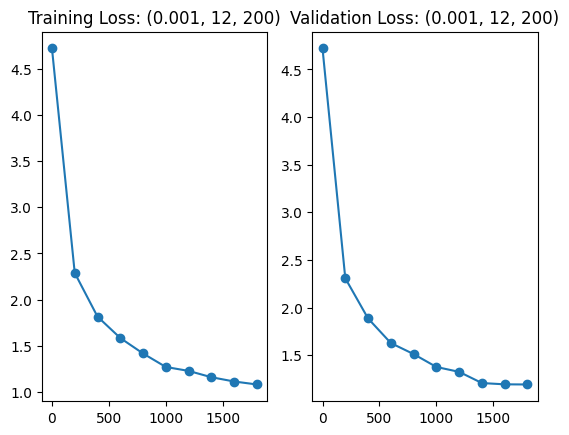

TrainConfigCPU(block_size=64, batch_size=12, max_iters=2000, eval_interval=200, eval_iters=50, lr=0.01, weight_decay=0.1, device='cpu', compile=False)
Parameters: 0.827392 M
-----------TRAINING THE MODEL WITH: (0.01, 12, 200)-----------


training: 100%|██████████| 2000/2000 [01:30<00:00, 22.05it/s, train=2.21, val=2.27]


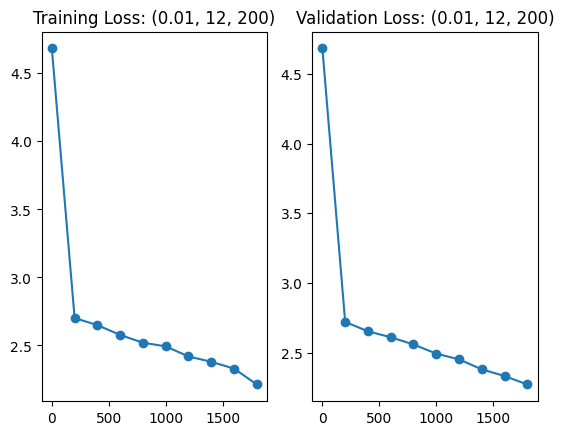

TrainConfigCPU(block_size=64, batch_size=32, max_iters=2000, eval_interval=200, eval_iters=50, lr=0.001, weight_decay=0.1, device='cpu', compile=False)
Parameters: 0.827392 M
-----------TRAINING THE MODEL WITH: (0.001, 32, 200)-----------


training: 100%|██████████| 2000/2000 [02:53<00:00, 11.53it/s, train=0.882, val=1.02]


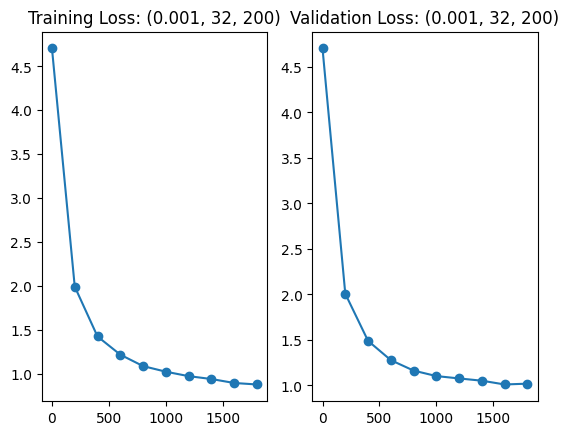

TrainConfigCPU(block_size=64, batch_size=12, max_iters=2000, eval_interval=400, eval_iters=50, lr=0.001, weight_decay=0.1, device='cpu', compile=False)
Parameters: 0.827392 M
-----------TRAINING THE MODEL WITH: (0.001, 12, 400)-----------


training: 100%|██████████| 2000/2000 [01:21<00:00, 24.63it/s, train=1.11, val=1.18]


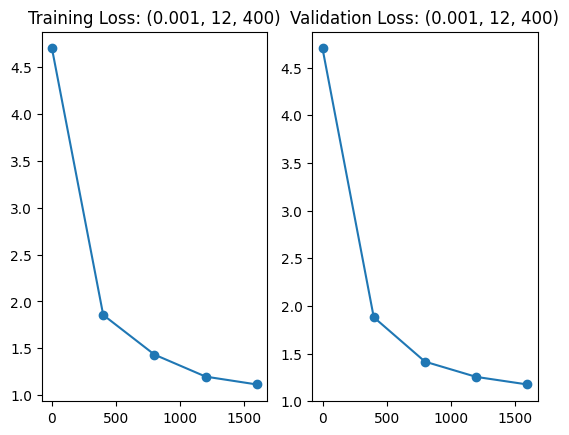

In [32]:
for i in range(len(hyperparameters)): 
  # GET HYPERPARAMETERS
  # Configuration for CPU
  @dataclass
  class TrainConfigCPU:
      block_size: int = 64
      batch_size: int = hyperparameters[i]['batch_size']
      max_iters: int = 2000
      eval_interval: int = hyperparameters[i]['eval_interval']
      eval_iters: int = 50
      lr: float = hyperparameters[i]['lr']
      weight_decay: float = 0.1
      device: str = "cpu"
      compile: bool = False

  # Configuration for CPU
  @dataclass
  class ModelConfigCPU:
      vocab_size: int
      block_size: int
      n_layer: int = 4
      n_head: int = 4
      n_embd: int = 128
      dropout: float = 0

  ModelConfig = ModelConfigCPU
  TrainConfig = TrainConfigCPU

  class CausalSelfAttention(nn.Module):
      def __init__(self, c: ModelConfig):
          super().__init__()
          assert c.n_embd % c.n_head == 0
          self.n_head = c.n_head
          self.head_dim = c.n_embd // c.n_head

          self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
          self.proj = nn.Linear(c.n_embd, c.n_embd, bias=False)
          self.dropout = nn.Dropout(c.dropout)

          mask = torch.tril(torch.ones(c.block_size, c.block_size)).view(1, 1, c.block_size, c.block_size)
          self.register_buffer("mask", mask)

      def forward(self, x):
          B, T, C = x.shape
          qkv = self.qkv(x)
          q, k, v = qkv.split(C, dim=2)

          q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
          k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
          v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

          att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
          att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
          att = F.softmax(att, dim=-1)
          att = self.dropout(att)

          y = att @ v
          y = y.transpose(1, 2).contiguous().view(B, T, C)
          y = self.proj(y)
          y = self.dropout(y)
          return y

  class MLP(nn.Module):
      def __init__(self, c: ModelConfig):
          super().__init__()
          self.fc = nn.Linear(c.n_embd, 4 * c.n_embd)
          self.proj = nn.Linear(4 * c.n_embd, c.n_embd)
          self.dropout = nn.Dropout(c.dropout)

      def forward(self, x):
          x = self.fc(x)
          x = F.gelu(x)
          x = self.proj(x)
          x = self.dropout(x)
          return x

  class Block(nn.Module):
      def __init__(self, c: ModelConfig):
          super().__init__()
          self.ln1 = nn.LayerNorm(c.n_embd)
          self.attn = CausalSelfAttention(c)
          self.ln2 = nn.LayerNorm(c.n_embd)
          self.mlp = MLP(c)

      def forward(self, x):
          x = x + self.attn(self.ln1(x))
          x = x + self.mlp(self.ln2(x))
          return x

  class NanoGPT(nn.Module):
      def __init__(self, c: ModelConfig):
          super().__init__()
          self.c = c
          self.tok_emb = nn.Embedding(c.vocab_size, c.n_embd)
          self.pos_emb = nn.Embedding(c.block_size, c.n_embd)
          self.drop = nn.Dropout(c.dropout)
          self.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layer)])
          self.ln_f = nn.LayerNorm(c.n_embd)
          self.head = nn.Linear(c.n_embd, c.vocab_size, bias=False)

          self.apply(self._init_weights)

      def _init_weights(self, module):
          if isinstance(module, (nn.Linear, nn.Embedding)):
              nn.init.normal_(module.weight, mean=0.0, std=0.02)
          if isinstance(module, nn.Linear) and module.bias is not None:
              nn.init.zeros_(module.bias)

      def forward(self, idx, targets=None):
          B, T = idx.shape
          assert T <= self.c.block_size
          pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

          x = self.tok_emb(idx) + self.pos_emb(pos)
          x = self.drop(x)
          for blk in self.blocks:
              x = blk(x)
          x = self.ln_f(x)
          logits = self.head(x)

          loss = None
          if targets is not None:
              loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
          return logits, loss

  cfg = TrainConfig()
  new_mcfg = ModelConfig(vocab_size=vocab_size, block_size=cfg.block_size)
  print(cfg)

  model = NanoGPT(new_mcfg).to(cfg.device)
  print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")

  # TRAIN THE MODEL with new hyperpar
  print(f"-----------TRAINING THE MODEL WITH: {hyperparameters[i]['lr'], hyperparameters[i]['batch_size'], hyperparameters[i]['eval_interval']}-----------")
  @torch.no_grad()
  def estimate_loss():
      model.eval()
      out = {}
      for split in ["train", "val"]:
          losses = torch.zeros(cfg.eval_iters)
          for k in range(cfg.eval_iters):
              X, Y = get_batch(split)
              _, loss = model(X, Y)
              losses[k] = loss.item()
          out[split] = losses.mean().item()
      model.train()
      return out

  optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

  losses_train = []
  losses_val = []
  model.train()
  pbar = tqdm(range(cfg.max_iters), desc="training")
  for it in pbar:
      if it % cfg.eval_interval == 0:
          losses = estimate_loss()
          losses_train.append(losses["train"])
          losses_val.append(losses["val"])
          pbar.set_postfix(train=losses["train"], val=losses["val"])

      xb, yb = get_batch("train")
      _, loss = model(xb, yb)

      optimizer.zero_grad(set_to_none=True)
      loss.backward()
      optimizer.step()


  epochs=range(0, cfg.max_iters, cfg.eval_interval)
  # MAKE A PLOT of Train and Val
  plt.subplot(1, 2, 1) # First plot
  plt.plot(epochs, losses_train, marker='o')
  plt.title(f"Training Loss: {hyperparameters[i]['lr'], hyperparameters[i]['batch_size'], hyperparameters[i]['eval_interval']}")

  plt.subplot(1, 2, 2) # Second plot
  plt.plot(epochs, losses_val, marker='o')
  plt.title(f"Validation Loss: {hyperparameters[i]['lr'], hyperparameters[i]['batch_size'], hyperparameters[i]['eval_interval']}")
  # plt.tight_layout()
  plt.show()

## Observations

The loss curves for the various configurations demonstrate that a low learning rate (0.001) results in smooth and stable convergence, with training and validation loss decreasing together and reaching comparable values, indicating neither underfitting nor overfitting.Reduced generalisation and mild instability are reflected in the noisier curves and wider gap between training and validation loss when the learning rate is increased to 0.01.Curve smoothness is impacted by changing the batch size from 12 to 32. While smaller batches introduce a little noise because of higher gradient variance, larger batches result in smoother, more monotonic loss reduction. The evaluation interval has no effect on the real learning dynamics; it only affects the number of points that show up on the plots. The only indication of overfitting or unstable training is seen with the higher learning rate, where the validation loss decreases more slowly and deviates slightly from the training loss. Overall, none of the runs exhibit obvious underfitting because both losses keep declining.

### Logs
#### First Flipped Classroom

**Role**: Clients

**Description**:
The list of materials that we have prepared before the session, in addition to the lecture materials:
- Birhane, A., Kalluri, P., Card, D., Agnew, W., Dotan, R., & Bao, M. (2022). The Values Encoded in Machine Learning Research. 2022 ACM Conference on Fairness, Accountability, and Transparency. https://doi.org/10.1145/3531146.3533083
- Alammar, Jay. “The Illustrated Transformer.” Jalammar.github.io, 27 June 2018, jalammar.github.io/illustrated-transformer/

The course of the discussion went based on the previously-prepared questions such as:
1) What is the role of temperature in a language model ? How does it differ from probability of the output token?
Short answer: Token temperature - is the list of probabilities with which the model will assign some token as the next predicted word; Temperature - is the user adjusted list of probabilities, which correct for the fact how deterministic the models outputs are.

2) What is the impact of the level of tokenisation (word-level / sentence-level / n-gram tokenisation) on the reliability of the outputs of the language models? And how should this be encountered in the context of developing/fine-tuning language models for medical imaging tasks?
Short answer: Level of tokenisation directly influences how the LM generalises, it’s understanding of semantic meaning across different contexts, and how much data is required for training, amongst other metrics. Therefore - selection of the character-level tokenisation for medical imaging tasks helps tackle the issues which would arise with other tokenisation levels such as: vocanulary explosion; caused by many out-of-vocabulary terms that would get generated in such case; the need for pre-defined dictionaty of sentences, and as a result inflexibility towards new slightly modified terms.

3) How should learning rate be adjusted given the level of tokenisation for medical imaging tasks, given it’s impact on the reliability of the generated output?
Short answer: For this question it is important to understand the clear definition of these terms, as well as to understand what do they influence in the model. Learning rate is responsible for “how fast the model is learning from the given bunch of input”, or in other words - how detailed the model sees it’s input. When the character-level tokenisation (which is recommended for the medical imaging tasks) is implemented - it is important that the model “sees” all those characters closely, therefore, for meaningful model training it should be lower, such that the model is more aware of the small details of the input.

#### Second Flipped Classroom


**Role**: Consultants

**Description**:
The list of materials that we have prepared before the session, in addition to the lecture materials:
- Daniel, Jurafsky, and James Martin. Speech and Language Processing. (Chapter 9: Transformers)
- Daniel, Jurafsky, and James Martin. Speech and Language Processing. (Chapter 11: Masked Language Models)

The course of the discussion went based on the questions we have received as consultants:
1) any tips for the assignment questions
- use google colab

2) what difference were found in generated text with(out) <ENDC>
- without doesn’t make sense (repetitive) -> confusing different inputs

3) did you observe changes in ex 2? And why?
- a little change but not much, we don’t know why. We don’t see overfitting, validation and training loss stay similar. High learning rate, little unstable.
4) changes in uppercase/lower case
- some small changes observed in different use of case but no significant differences

5) what did you use for plotting
- matplotlib

6) what effect had the generating parameters on the generated sentences?
- high temperature: many grammatical incorrect words, high k-top: sentences even more chaotic